<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_5_SLR_Transformations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: Transformations (Bending the Line)

Author: Brad Sheese

---

## What This Notebook Is About

In Notebook 17_1_3 we saw the Auto MPG model fail the **L**inearity assumption: a straight line through data that's clearly curving, producing U-shaped residuals. At the time we said *"transformations will fix this"* and moved on. Time to make good on that promise.

The whole dilemma can be summarized in one slogan:

> **You can't bend the OLS line — but you *can* bend the data.**

OLS always produces a straight line. That's non-negotiable. So if a line is wrong for your data, you have two choices: abandon OLS for something nonlinear (neural nets, splines, trees), or **rewrite your variables** so a straight line becomes correct.

That second option is what this notebook is about. Our running example will be one of the most famous curved relationships in data science: **GDP per capita vs. life expectancy** (Gapminder data).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sns.set_style('whitegrid')
rng = np.random.default_rng(seed=42)

# Gapminder 2007 snapshot.
url = 'https://raw.githubusercontent.com/bsheese/cs377/main/data/gapminderDataFiveYear.csv'
gapminder = pd.read_csv(url)
gap = gapminder[gapminder['year'] == 2007].reset_index(drop=True)

print(f'Countries: {len(gap)}')
gap[['country', 'continent', 'gdpPercap', 'lifeExp']].head()

Countries: 142


,country,continent,gdpPercap,lifeExp
0,Afghanistan,Asia,974.580338,43.828
1,Albania,Europe,5937.029526,76.423
2,Algeria,Africa,6223.367465,72.301
3,Angola,Africa,4797.231267,42.731
4,Argentina,Americas,12779.379640,75.320


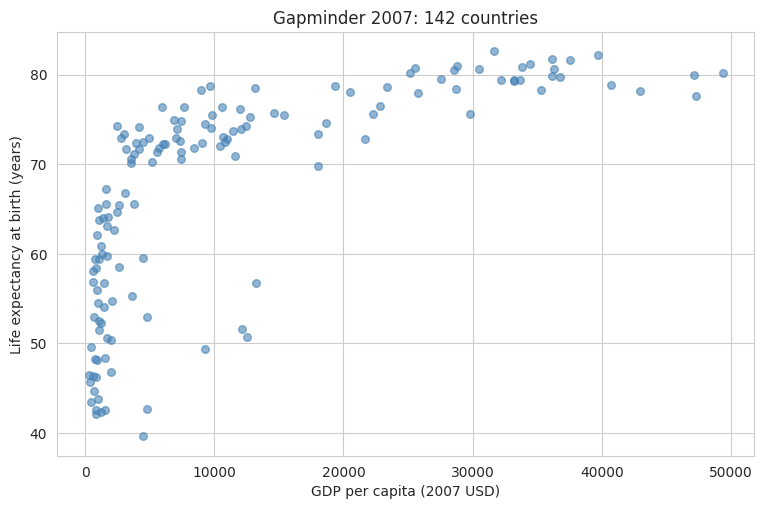

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(gap['gdpPercap'], gap['lifeExp'], s=30, alpha=0.6, color='steelblue')
ax.set_xlabel('GDP per capita (2007 USD)')
ax.set_ylabel('Life expectancy at birth (years)')
ax.set_title('Gapminder 2007: 142 countries')
plt.show()

---

## Section 1: The Failing Model

We know from 17_1_3 what happens when you fit a straight line to a curve. Let's do it quickly to set the baseline.

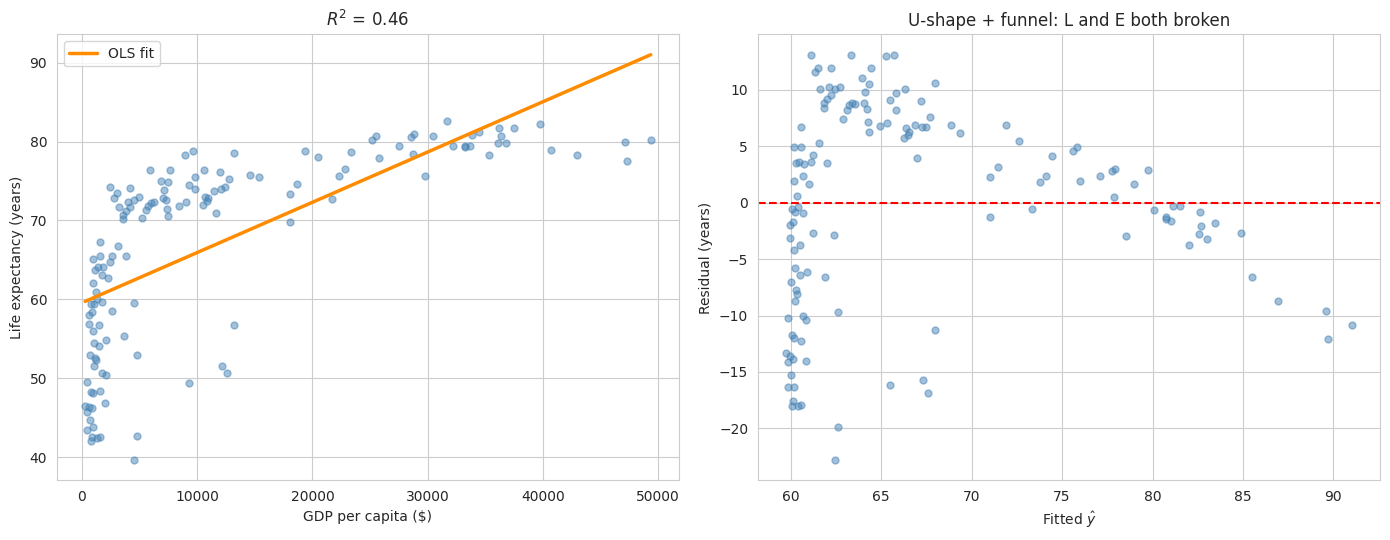

Slope: 0.000637  |  Intercept: 59.57  |  $R^2$: 0.461


In [3]:
x, y = gap['gdpPercap'], gap['lifeExp']
model_raw = sm.OLS(y, sm.add_constant(x)).fit()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x_grid = np.linspace(x.min(), x.max(), 200)
axes[0].scatter(x, y, s=25, alpha=0.5, color='steelblue')
axes[0].plot(x_grid, model_raw.predict(sm.add_constant(x_grid)),
             color='darkorange', linewidth=2.5, label='OLS fit')
axes[0].set_xlabel('GDP per capita ($)')
axes[0].set_ylabel('Life expectancy (years)')
axes[0].set_title(f'$R^2$ = {model_raw.rsquared:.2f}')
axes[0].legend()

axes[1].scatter(model_raw.fittedvalues, model_raw.resid, s=25, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted $\\hat{y}$')
axes[1].set_ylabel('Residual (years)')
axes[1].set_title('U-shape + funnel: L and E both broken')

plt.tight_layout()
plt.show()
print(f'Slope: {model_raw.params["gdpPercap"]:.6f}  |  Intercept: {model_raw.params["const"]:.2f}  |  $R^2$: {model_raw.rsquared:.3f}')

The line under-predicts for poor and rich countries and over-predicts in the middle. The U-shaped residual curve confirms the relationship is not linear. Time to fix it.

---

## Section 2: Why Log?

Look at the scatterplot again. The curve shows **diminishing returns**: each additional dollar of GDP buys less life expectancy than the dollar before. The slope decreases as $x$ increases.

We need a function of $x$ whose *own* slope also decreases as $x$ grows. The natural log does exactly this:

$$\frac{d}{dx} \log(x) = \frac{1}{x}$$

When $x$ is small, $1/x$ is large (steep). When $x$ is large, $1/x$ is tiny (flat). That's exactly the shape our scatterplot shows. This is why log transformations are the default choice for relationships with diminishing returns.

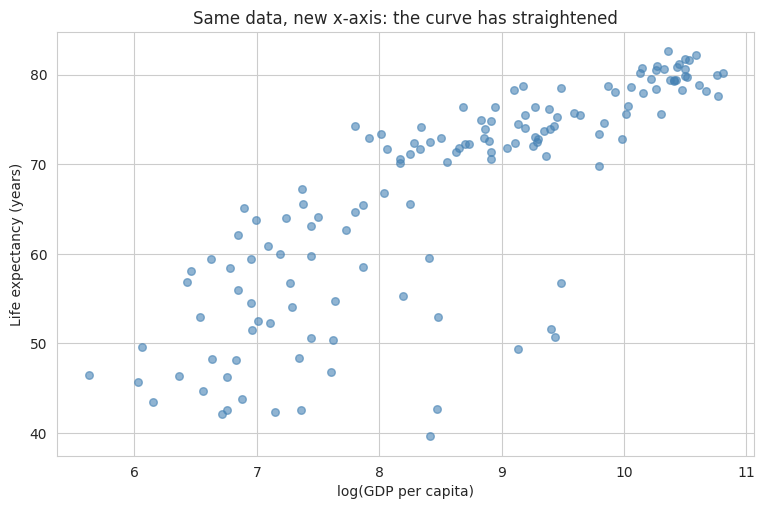

In [4]:
gap['log_gdp'] = np.log(gap['gdpPercap'])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(gap['log_gdp'], gap['lifeExp'], s=30, alpha=0.6, color='steelblue')
ax.set_xlabel('log(GDP per capita)')
ax.set_ylabel('Life expectancy (years)')
ax.set_title('Same data, new x-axis: the curve has straightened')
plt.show()

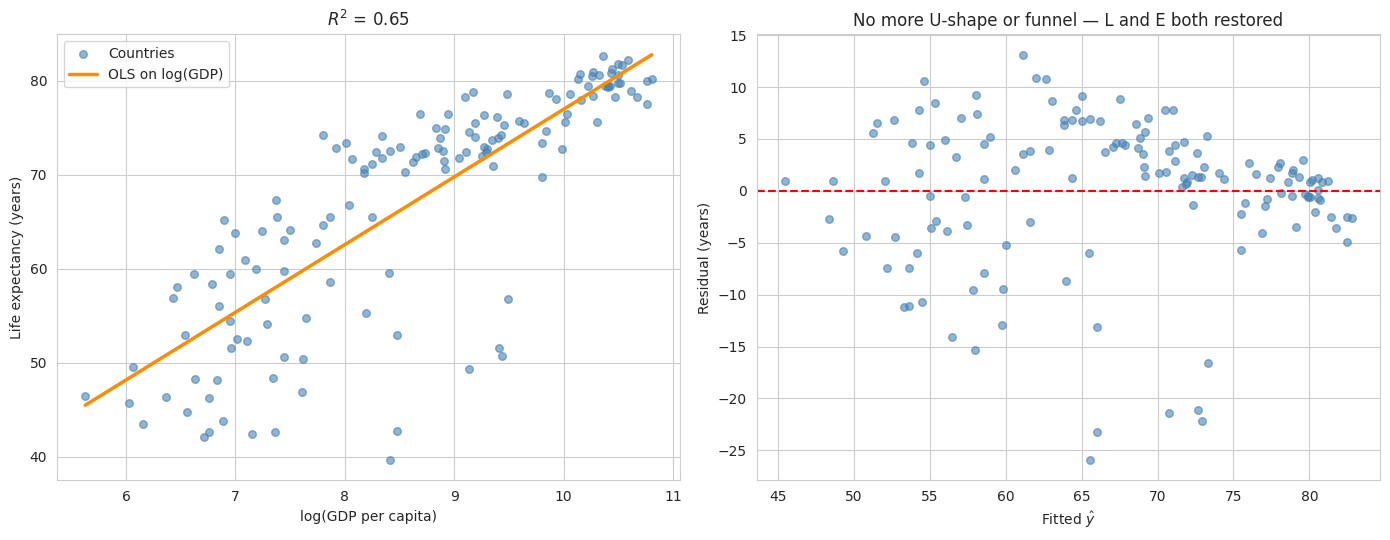

$R^2$ improved from 0.461 to 0.654


In [5]:
model_log = sm.OLS(gap['lifeExp'], sm.add_constant(gap['log_gdp'])).fit()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

xlg = np.linspace(gap['log_gdp'].min(), gap['log_gdp'].max(), 200)
axes[0].scatter(gap['log_gdp'], gap['lifeExp'], s=30, alpha=0.6, color='steelblue', label='Countries')
axes[0].plot(xlg, model_log.predict(sm.add_constant(xlg)),
             color='darkorange', linewidth=2.5, label='OLS on log(GDP)')
axes[0].set_xlabel('log(GDP per capita)')
axes[0].set_ylabel('Life expectancy (years)')
axes[0].set_title(f'$R^2$ = {model_log.rsquared:.2f}')
axes[0].legend()

axes[1].scatter(model_log.fittedvalues, model_log.resid, s=30, alpha=0.6, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted $\\hat{y}$')
axes[1].set_ylabel('Residual (years)')
axes[1].set_title('No more U-shape or funnel — L and E both restored')

plt.tight_layout()
plt.show()
print(f'$R^2$ improved from {model_raw.rsquared:.3f} to {model_log.rsquared:.3f}')

The line now hugs the data and $R^2$ jumped from 0.46 to 0.65. More importantly, look at the before-and-after residuals: the U-shape (broken **L**inearity) is gone, and so is the funnel (broken **E**qual variance) — both violations flagged in Section 1 are fixed by a single transformation. The inferential statistics (SE, p-values, CIs) are trustworthy again.

But now the slope means something different. Section 3 is how to read it.

---

## Section 3: Interpreting a Log-Linear Slope

Our model is $\text{life\_exp} = \beta_0 + \beta_1 \log(\text{gdp})$. What does $\beta_1$ mean?

### Option A: Calculus (if you have it)

$$\frac{dy}{dx} = \beta_1 \cdot \frac{1}{x} \quad\Longleftrightarrow\quad dy = \beta_1 \cdot \frac{dx}{x}$$

Since $dx/x$ is a proportional change in $x$, a 1% increase in $x$ ($dx/x = 0.01$) gives $dy = \beta_1 \cdot 0.01$ change in $y$.

> **A 1% increase in GDP is associated with a $\beta_1 / 100$ unit change in life expectancy.**

### Option B: Algebra (no calculus needed)

Compare two countries where one has 1% higher GDP. Let $x_2 = 1.01 \cdot x_1$. Then:

$$y_2 - y_1 = \beta_1 (\log x_2 - \log x_1) = \beta_1 \cdot \log(1.01) \approx \beta_1 \cdot 0.00995 \approx \beta_1 / 100$$

Same result. Let's apply it.

In [6]:
beta = model_log.params['log_gdp']

print(f'Slope: {beta:.4f} years per log-unit of GDP')
print()
print('A 1% increase in GDP is associated with:')
print(f'  {beta / 100:.4f} years  ({beta / 100 * 365:.1f} days) of life expectancy')
print()
print('Concrete examples:')
print(f'  Doubling GDP (e.g., $5K \u2192 $10K):  +{beta * np.log(2):.2f} years')
print(f'  10\u00d7 GDP (e.g., $1K \u2192 $10K):    +{beta * np.log(10):.2f} years')

Slope: 7.2028 years per log-unit of GDP

A 1% increase in GDP is associated with:
  0.0720 years  (26.3 days) of life expectancy

Concrete examples:
  Doubling GDP (e.g., $5K → $10K):  +4.99 years
  10× GDP (e.g., $1K → $10K):    +16.59 years


These numbers align with real-world development economics: doubling GDP per capita is associated with about 5 extra years of life expectancy.

### The four log-model forms you'll see in practice

| Model | Formula | Slope says |
|---|---|---|
| **Level–level** (plain OLS) | $y = \beta_0 + \beta_1 x$ | +1 unit of $x$ ⇒ +$\beta_1$ units of $y$ |
| **Level–log** ($\log x$ only) | $y = \beta_0 + \beta_1 \log x$ | +1% in $x$ ⇒ +$\beta_1/100$ units of $y$ *(our fit)* |
| **Log–level** ($\log y$ only) | $\log y = \beta_0 + \beta_1 x$ | +1 unit of $x$ ⇒ +$100 \beta_1\%$ change in $y$ |
| **Log–log** (both) | $\log y = \beta_0 + \beta_1 \log x$ | +1% in $x$ ⇒ +$\beta_1\%$ change in $y$ (pure elasticity) |

---

**YOUR TURN (10 min):** Fit a log–level model: $\log(\text{lifeExp}) = \beta_0 + \beta_1 \cdot \text{gdpPercap}$. Look at the residual plot. Which fits better — level–log or log–level?

> **Caution on $R^2$:** The two models predict *different outcomes* ($\text{lifeExp}$ vs. $\log(\text{lifeExp})$), so their $R^2$ values measure variance on different scales and cannot be compared meaningfully. Always compare residual *patterns*, not raw $R^2$, whenever the $y$-variable has changed.

How would you interpret $\beta_1$ in the log–level model?

---

## Section 4: Box-Cox — Let the Data Choose

We applied $\log(\text{GDP})$ because the scatter showed diminishing returns and we know $d/dx\,\log(x) = 1/x$ has exactly the right shape. But in practice you won't always have a clear physical story. **Box-Cox is a systematic way to let the data suggest a transformation before you commit.**

Box-Cox tries a family of power transformations parameterized by $\lambda$:

$$y^{(\lambda)} = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \lambda \neq 0 \\ \log y & \lambda = 0 \end{cases}$$

It automatically finds the $\lambda$ that makes the distribution most normal — which typically also makes linear relationships more linear. Special cases: $\lambda = 0$ is log, $\lambda = 0.5$ is square root, $\lambda = -1$ is reciprocal, $\lambda = 1$ means no transformation needed.

**Use it as a discovery tool.** Run Box-Cox on both $x$ and $y$ before making a choice. If it returns $\lambda \approx 0$ for $x$, that's evidence for $\log(x)$. If it returns $\lambda \approx 1$ for $y$, leave $y$ alone. Then let physics or domain knowledge confirm — Box-Cox is a pointer, not a proof.

In [7]:
# Box-Cox as a discovery tool: run on both x and y BEFORE choosing.

# On x: GDP per capita
gdp_vals = gap['gdpPercap']
_, lam_gdp = stats.boxcox(gdp_vals)
print(f'Box-Cox on GDP per capita:      lambda = {lam_gdp:.3f}')
print(f'  → near 0 (log) — confirms our x transformation')
print()

# On y: life expectancy (would we need to transform y too?)
lifeexp_vals = gap['lifeExp']
_, lam_life = stats.boxcox(lifeexp_vals)
print(f'Box-Cox on life expectancy:     lambda = {lam_life:.3f}')
print(f'  → well above 1 — a surprise! See the discussion below')
print()

# Displacement from the MPG dataset (used in Section 5).
mpg_data = sns.load_dataset('mpg').dropna()
_, lam_disp = stats.boxcox(mpg_data['displacement'])
print(f'Box-Cox on displacement (MPG):  lambda = {lam_disp:.3f}')
print(f'  → about -0.3: between log (0) and reciprocal (-1), pointing the same direction as the physics below')

Box-Cox on GDP per capita:      lambda = 0.068
  → near 0 (log) — confirms our x transformation

Box-Cox on life expectancy:     lambda = 3.073
  → well above 1 — a surprise! See the discussion below

Box-Cox on displacement (MPG):  lambda = -0.288
  → about -0.3: between log (0) and reciprocal (-1), pointing the same direction as the physics below


Box-Cox pointed at $\lambda \approx 0$ (log) for GDP — confirming our $x$ transformation. For life expectancy it returned $\lambda \approx 3$, which would mean *cubing* $y$. We are not going to do that, and the reason why is the most instructive part of this section: life expectancy is left-skewed, so Box-Cox (which only looks at $y$'s own distribution) wants to stretch its left tail toward normality. But our residual diagnostics already showed that logging $x$ and leaving $y$ alone satisfies the LINE assumptions. This is caveat #1 below in action — Box-Cox optimizes the *variable's* normality, not the *relationship*, and the residual plot outranks it. For displacement it returned $\lambda \approx -0.3$, between log ($\lambda = 0$) and reciprocal ($\lambda = -1$) — a useful signal that something in that direction is needed, which the physics confirms.

Two caveats to keep in mind:

1. **Box-Cox optimizes for normality, not for fit.** The $\lambda$ that produces the most normal distribution and the $\lambda$ that best satisfies LINE are usually close but not identical. Always recheck residuals after any transformation it suggests.
2. **Box-Cox requires strictly positive values.** If $x$ or $y$ can be zero or negative, shift first (use $x + c$) or choose a different approach.

Use Box-Cox as the opening move in a conversation with your data — then let the residual plot have the final word.

---

## Section 5: Fixing the MPG Model from 17_1_3

Back in 17_1_3 we saw `mpg` vs. `displacement` produce a U-shaped residual plot. The physics suggests the fix: fuel consumption (gallons *per* mile) is roughly proportional to engine size. If $1/\text{mpg} \approx a + b \cdot \text{displacement}$, then $\text{mpg} \approx a + b/\text{displacement}$.

Let's verify the physics first by checking that $1/\text{mpg}$ really is linear in displacement.

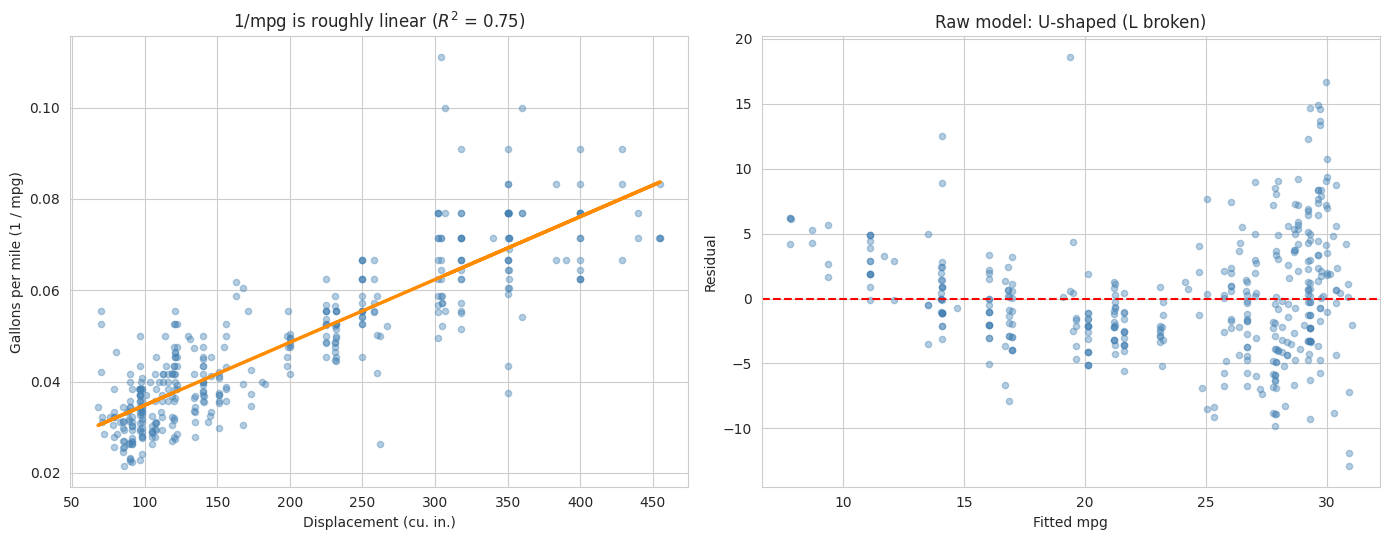

1/mpg model R^2: 0.750


In [8]:
mpg = sns.load_dataset('mpg').dropna().reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: verify the physics — gpm (1/mpg) vs displacement
gpm_model = sm.OLS(1.0 / mpg['mpg'], sm.add_constant(mpg['displacement'])).fit()
axes[0].scatter(mpg['displacement'], 1.0 / mpg['mpg'], s=20, alpha=0.4, color='steelblue')
axes[0].plot(mpg['displacement'], gpm_model.predict(sm.add_constant(mpg['displacement'])),
             color='darkorange', linewidth=2.5)
axes[0].set_xlabel('Displacement (cu. in.)')
axes[0].set_ylabel('Gallons per mile (1 / mpg)')
axes[0].set_title(f'1/mpg is roughly linear ($R^2$ = {gpm_model.rsquared:.2f})')

# Right: raw model residuals (from 17_1_3)
raw = sm.OLS(mpg['mpg'], sm.add_constant(mpg['displacement'])).fit()
axes[1].scatter(raw.fittedvalues, raw.resid, s=20, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted mpg')
axes[1].set_ylabel('Residual')
axes[1].set_title('Raw model: U-shaped (L broken)')

plt.tight_layout()
plt.show()
print(f'1/mpg model R^2: {gpm_model.rsquared:.3f}')

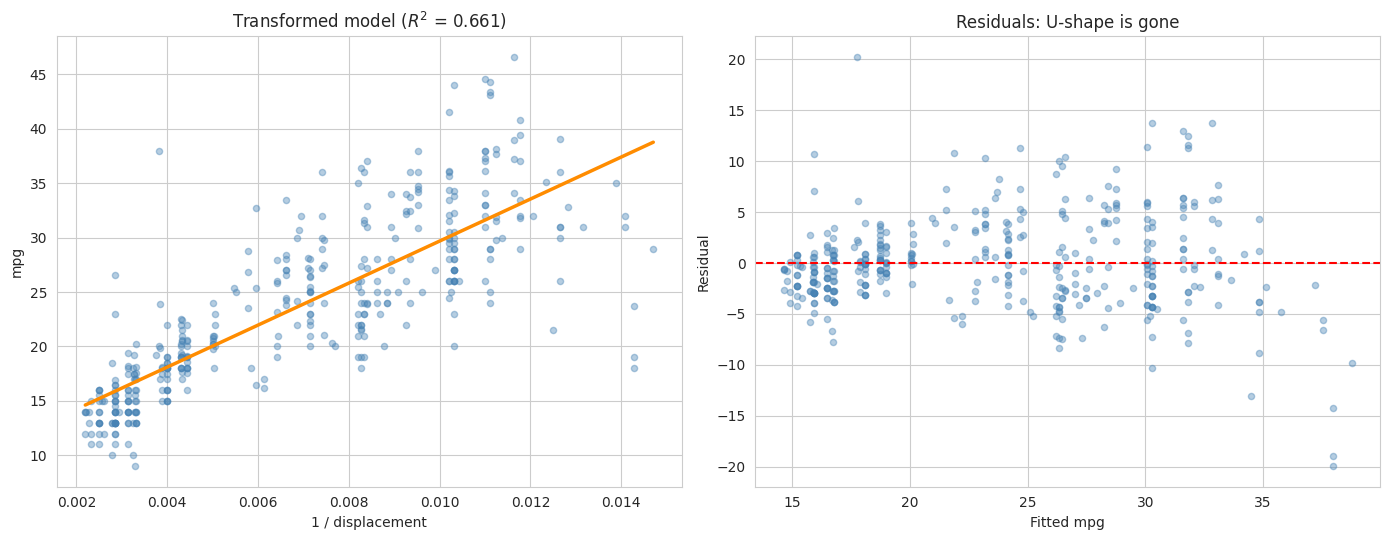

Slope (on 1/displacement): 1929.9  mpg per unit of 1/cu.in.
Intercept:                 10.38  mpg  (extrapolated limit as displacement → ∞)
Raw model R^2:             0.648
Transformed model R^2:     0.661


In [9]:
# Now apply the reciprocal transformation to x and re-fit.
mpg['inv_disp'] = 1.0 / mpg['displacement']
fixed = sm.OLS(mpg['mpg'], sm.add_constant(mpg['inv_disp'])).fit()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

inv_grid = np.linspace(mpg['inv_disp'].min(), mpg['inv_disp'].max(), 200)
axes[0].scatter(mpg['inv_disp'], mpg['mpg'], s=20, alpha=0.4, color='steelblue')
axes[0].plot(inv_grid, fixed.predict(sm.add_constant(inv_grid)),
             color='darkorange', linewidth=2.5)
axes[0].set_xlabel('1 / displacement')
axes[0].set_ylabel('mpg')
axes[0].set_title(f'Transformed model ($R^2$ = {fixed.rsquared:.3f})')

axes[1].scatter(fixed.fittedvalues, fixed.resid, s=20, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted mpg')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals: U-shape is gone')

plt.tight_layout()
plt.show()
slope = fixed.params['inv_disp']
print(f'Slope (on 1/displacement): {slope:.1f}  mpg per unit of 1/cu.in.')
print(f'Intercept:                 {fixed.params["const"]:.2f}  mpg  (extrapolated limit as displacement → ∞)')
print(f'Raw model R^2:             {raw.rsquared:.3f}')
print(f'Transformed model R^2:     {fixed.rsquared:.3f}')

The $R^2$ bump is modest (0.648 → 0.661), but look at the residual plot: the U-shape is essentially gone. The inferential statistics are now trustworthy again. This is the real win — $R^2$ isn't everything.

**Reading the slope.** The model is $\hat{\text{mpg}} = \hat{\beta}_0 + \hat{\beta}_1 \cdot (1/\text{displacement})$. Because 1/displacement is a small number (roughly 0.003–0.010 across cars in this dataset), the slope $\hat{\beta}_1$ appears large — don't be alarmed. The practical interpretation: the predicted mpg difference between two cars is $\hat{\beta}_1 \times (1/d_1 - 1/d_2)$. For example, going from a large V8 at 350 cu.in. to a small four-cylinder at 140 cu.in. changes 1/displacement by $1/140 - 1/350 \approx 0.0043$, so the predicted mpg gain is $\hat{\beta}_1 \times 0.0043$. Plug in the printed slope to get the number.

> **The right metric for a successful transformation is the residual plot, not the $R^2$.** A transformation that fixes a major residual pattern is more valuable than one that bumps $R^2$ by 0.05 while leaving residuals curved.

---

**YOUR TURN (10 min):** Try a square-root transformation on displacement: $\text{mpg} = a + b \cdot \sqrt{\text{displacement}}$. Compare the $R^2$ and residual plot to the reciprocal model. Which works better?

---

## A Few Honest Warnings

1. **The slope's meaning changes.** After a log transformation, the slope is an elasticity, not a unit-per-unit effect. Always report the transformation and spell out the interpretation.
2. **You can't log (or square-root) non-positive values.** GDP and body mass are positive; temperatures or profits may not be. If $x$ can be zero, use $\log(1+x)$ or a different transformation. If $x$ can be negative, log won't work at all.
3. **Predictions have to be back-transformed.** If you modeled $\log y$, your predictions live on the log scale: $\widehat{\log y}$. Exponentiate to recover $y$-unit predictions. But $\exp(\widehat{\log y})$ slightly underestimates $y$ on average — Jensen's inequality shows that $E[e^Z] > e^{E[Z]}$. The corrected prediction is $\exp(\widehat{\log y}) \cdot \exp(\hat{\sigma}^2 / 2)$, where $\hat{\sigma}^2$ is the residual variance from the log-scale fit. For exploratory work the correction is often negligible; for serious forecasting, apply it.
4. **A transformation that *hides* a problem isn't the same as one that *solves* it.** The test is always the residual plot. If patterns remain, the transformation didn't work.
5. **$R^2$ values across different $y$-scales are not comparable.** A model with $y$ vs. one with $\log y$ measures variance on different scales. Compare residual patterns, not raw $R^2$, whenever the outcome variable has changed.

---

## Reference: The Transformation Toolkit

| Transformation | Fixes what? | Use when the scatter looks like… |
|---|---|---|
| $\log(x)$ | Curve + funnel in $x$ | Diminishing returns; $x$ spans orders of magnitude |
| $\log(y)$ | Curve + funnel in $y$ | $y$ spans orders of magnitude; spread grows with mean |
| $\log(x)$ and $\log(y)$ | Both | Power laws — straight line on log-log axes |
| $1/x$ (reciprocal) | Asymptotic decay | $y$ approaches a floor as $x$ grows (e.g. MPG vs. displacement) |
| $\sqrt{x}$ | Mild curvature | Gentle concavity; less aggressive than log |
| $x^2, x^3$ (polynomial) | Turning points | U-shaped or hump-shaped relationships |
| **Box-Cox** | Automatically picks $\lambda$ | When you want the data to choose the best power transformation |

**Two rules of thumb:**
1. Try the transformation that physics/economics suggests first.
2. The best transformation makes the residual plot look boring.

---

## Putting It All Together

The transformation workflow:

> **Fit OLS → check residuals → if pattern shows, transform → refit → recheck → interpret carefully.**

And the core slogan:

> **You can't bend the line, but you can bend the data.**

Influence analysis (17_1_4) asks *"which rows are damaging the fit?"* Transformations ask *"which shape fits better?"* Sometimes the problem is a bad row; sometimes it's a bad shape. The diagnostics from 17_1_3 (residual plots, Q-Q plots) tell you which case you're dealing with.

Two demonstrations in this notebook:

| Dataset | Raw $R^2$ | Transformation | Transformed $R^2$ | Key win |
|---|---:|---|---|---|
| Gapminder | 0.46 | $\log$(GDP) | 0.65 | Curve and funnel both eliminated |
| Auto MPG | 0.65 | $1/$displacement | 0.66 | U-shape eliminated; inference restored |

*$R^2$ is comparable within each row because the outcome $y$ is unchanged (both Gapminder models predict life expectancy; both MPG models predict mpg). Had we also transformed $y$, the two $R^2$ values would measure variance on different scales and could not be compared directly.*

The small $R^2$ jump for MPG (0.65 → 0.66) is a reminder that the residual plot — not $R^2$ — is the primary diagnostic. A transformation that fixes a severe U-shape is a success even when $R^2$ barely moves.

---

**YOUR TURN (capstone, 15 min):** Using the Ames Housing dataset (`sns.load_dataset` won't work — use the OpenIntro URL from 17_1_4), fit `price ~ area`. Use Box-Cox to check whether `area` or `price` benefit from a transformation, apply whatever the data suggests, and show before-and-after residual plots. Write two sentences on what improved.

### Where We're Going Next

All five notebooks so far have been about the data we already have. But models are built to say something about **data we haven't seen yet**. A correctly-specified model (right shape, assumptions met) doesn't just describe the training data better — it generalizes better too. A misspecified model with violated LINE assumptions will often fail worse on new data than a transformed model that fixed those issues first.

In `17_1_6_SLR_GeneralizationTest.ipynb` we test this directly: we'll withhold data, fit the model, and score it on the held-out set — the universal discipline of machine learning.